# Stage 01 v2 — Intraday data preparation (ingestion delgada)

```
S01_intraday_data_preparation_v2.ipynb
```

## Alcance

Esta notebook **no contiene logica de negocio**. Toda la logica vive en
`src/data/s01_intraday_preparation.py`. Esta notebook solo la invoca y
muestra resultados.

- No modifica `notebooks/S01_intraday_data_preparation.ipynb` (v1, evidencia historica intacta).
- No modifica nada de S00 (`config/data_config.yaml`, `src/data/s00_raw_ingestion.py`, artefactos de `data/01_raw/`).
- No construye targets, features, secuencias ni ventanas de modelos -- eso pertenece a etapas posteriores.
- La ventana `04:30-16:00` y los 5 regimenes son decisiones ya aprobadas (ver plan de auditoria S01 v2); esta notebook no los vuelve a comparar.
- La hipotesis de zona horaria de origen **no se asume**: se evalua programaticamente contra 3 candidatos antes de convertir.

## 0. Configuracion del entorno

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path, marker: str = "config/intraday_config.yaml", max_levels: int = 15) -> Path:
    current = start.resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(
        f"No se encontro un ancestro de {start} que contenga {marker} en {max_levels} niveles"
    )


PROJECT_ROOT = find_project_root(Path.cwd())
print("Project root:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Project root: C:\Users\heguu\OneDrive\Escritorio\neural_profit


In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from src.data import s01_intraday_preparation as prep

CONFIG_PATH = PROJECT_ROOT / "config" / "intraday_config.yaml"
print("Config:", CONFIG_PATH)

Config: C:\Users\heguu\OneDrive\Escritorio\neural_profit\config\intraday_config.yaml


## 1. Ejecucion productiva

In [3]:
result = prep.run_s01_preparation(project_root=PROJECT_ROOT, config_path=CONFIG_PATH)

print("Reutilizo artefacto existente:", result.reused_existing)
print("Parquet:", result.parquet_path)
print("SHA-256 Parquet:", result.parquet_sha256)
print("Trading day audit:", result.audit_path)
print("Regime distribution:", result.regime_dist_path)
print("Manifest:", result.manifest_path)
print("Summary:", result.summary_path)
print("TZ validation:", result.tz_validation_path)

Reutilizo artefacto existente: False
Parquet: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2.parquet
SHA-256 Parquet: c8001e8e5660a1d77d0c84ccc472bba49ba7ca9f5d137a4c700278d3810c151c
Trading day audit: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\trading_day_audit_v2.parquet
Regime distribution: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\regime_distribution_v2.parquet
Manifest: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2_manifest.json
Summary: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2_summary.json
TZ validation: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\tz_validation_v2.json


## 2. Validacion programatica de zona horaria (3 hipotesis)

No se asume UTC. Se evaluan `UTC`, `America/New_York` y `America/Chicago`
contra la apertura 09:30 ET, el cierre 16:00 ET y el corte de mantenimiento
~17:00-18:00 ET, separando meses de horario de verano (EDT) y estandar (EST).

In [4]:
result.tz_table

,timezone_candidate,opening_alignment,closing_alignment,maintenance_break_alignment,dst_consistency,ambiguous_nonexistent_rows,total_alignment_score,conclusion,confidence_level
0,UTC,1,0,1,0,0,2.0,"opening off by 1min, closing off by 0min, main...",high
1,America/Chicago,29,29,999,30,1,1087.1,"opening off by 29min, closing off by 29min, ma...",low
2,America/New_York,38,59,999,9,1,1105.1,"opening off by 38min, closing off by 59min, ma...",low


In [5]:
print("timezone_selected:", result.manifest["timezone"]["timezone_selected"])
print("timezone_validation_status:", result.manifest["timezone"]["timezone_validation_status"])
print("timezone_provider_confirmation:", result.manifest["timezone"]["timezone_provider_confirmation"])
print("timezone_evidence:", result.manifest["timezone"]["timezone_evidence"])
print("confidence_level:", result.manifest["timezone"]["confidence_level"])

timezone_selected: UTC
timezone_validation_status: empirically_supported
timezone_provider_confirmation: False
timezone_evidence: inferred_from_market_structure_and_dst
confidence_level: high


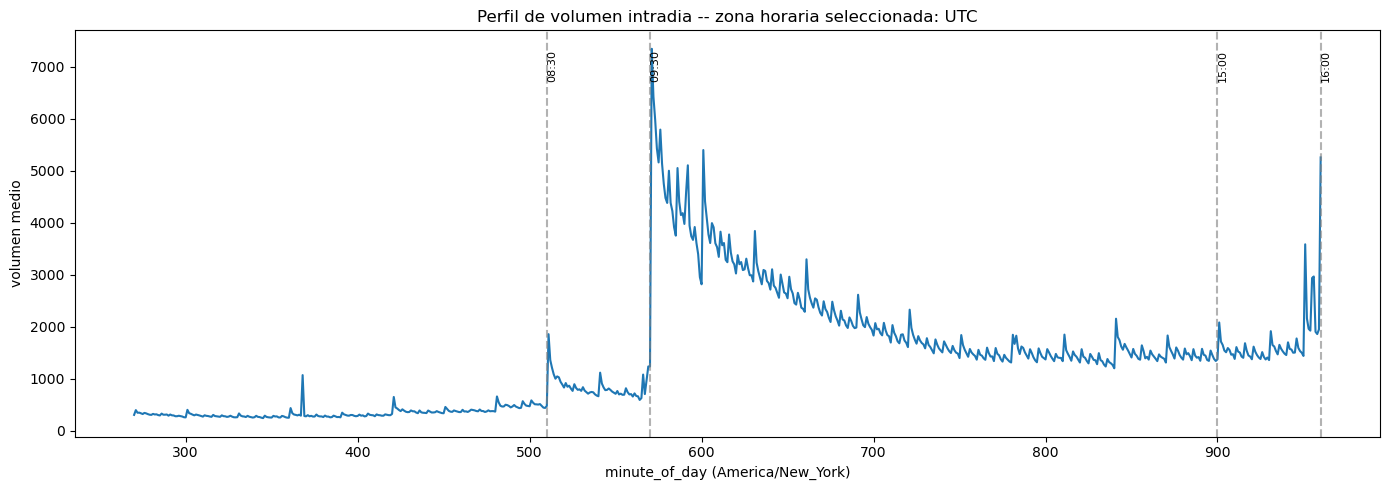

In [6]:
# Perfil de volumen por minuto local (America/New_York) tras aplicar la
# zona horaria ganadora -- confirmacion visual de los eventos estructurales.
df = result.df_window
profile = df.groupby("minute_of_day")["volume"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(profile.index, profile.values)
for m, label in [(510, "08:30"), (570, "09:30"), (900, "15:00"), (960, "16:00")]:
    ax.axvline(m, color="gray", linestyle="--", alpha=0.6)
    ax.text(m, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)
ax.set_xlabel("minute_of_day (America/New_York)")
ax.set_ylabel("volumen medio")
ax.set_title(f"Perfil de volumen intradia -- zona horaria seleccionada: {result.manifest['timezone']['timezone_selected']}")
plt.tight_layout()
plt.show()

## 3. Resultado del dataset intradia

In [7]:
print("Shape:", df.shape)
print("Columnas:", list(df.columns))
print("Rango:", df.index.min(), "->", df.index.max())
print("minute_of_day min/max:", df["minute_of_day"].min(), df["minute_of_day"].max())
df.head()

Shape: (1087777, 11)
Columnas: ['date', 'minute_of_day', 'regime_id', 'regime_label', 'consecutive_segment_id', 'open', 'high', 'low', 'close', 'volume', 'contract']
Rango: 2019-12-23 04:30:00-05:00 -> 2026-04-17 16:00:00-04:00
minute_of_day min/max: 270 960


,date,minute_of_day,regime_id,regime_label,consecutive_segment_id,open,high,low,close,volume,contract
datetime,,,,,,,,,,,
2019-12-23 04:30:00-05:00,2019-12-23,270,0,Early_Premarket,0,8718.25,8718.75,8718.25,8718.50,13,H20
2019-12-23 04:31:00-05:00,2019-12-23,271,0,Early_Premarket,0,8718.50,8719.25,8718.50,8719.25,22,H20
2019-12-23 04:32:00-05:00,2019-12-23,272,0,Early_Premarket,0,8719.25,8720.00,8719.00,8719.75,22,H20
2019-12-23 04:33:00-05:00,2019-12-23,273,0,Early_Premarket,0,8719.50,8720.25,8719.50,8719.75,60,H20
2019-12-23 04:34:00-05:00,2019-12-23,274,0,Early_Premarket,0,8719.50,8719.50,8719.00,8719.25,43,H20


In [8]:
df.tail()

,date,minute_of_day,regime_id,regime_label,consecutive_segment_id,open,high,low,close,volume,contract
datetime,,,,,,,,,,,
2026-04-17 15:56:00-04:00,2026-04-17,956,4,Closing,2284,26815.50,26829.00,26814.25,26820.00,4185,M26
2026-04-17 15:57:00-04:00,2026-04-17,957,4,Closing,2284,26819.75,26830.00,26815.00,26817.50,2536,M26
2026-04-17 15:58:00-04:00,2026-04-17,958,4,Closing,2284,26818.00,26824.50,26809.00,26823.75,2518,M26
2026-04-17 15:59:00-04:00,2026-04-17,959,4,Closing,2284,26823.50,26829.75,26820.00,26826.00,2731,M26
2026-04-17 16:00:00-04:00,2026-04-17,960,4,Closing,2284,26826.25,26832.00,26818.25,26828.00,8561,M26


## 4. Regimenes

Cinco regimenes, sin ruta default (todo minuto de la ventana cae en
exactamente un regimen; la barra de 16:00 pertenece a `Closing`, corrigiendo
el bug historico).

In [9]:
result.regime_dist

,regime_id,regime_label,n_bars,n_days
0,0,Early_Premarket,383822,1626
1,1,Premarket,96151,1614
2,2,Opening,94746,1639
3,3,Regular,420074,1692
4,4,Closing,92984,1561


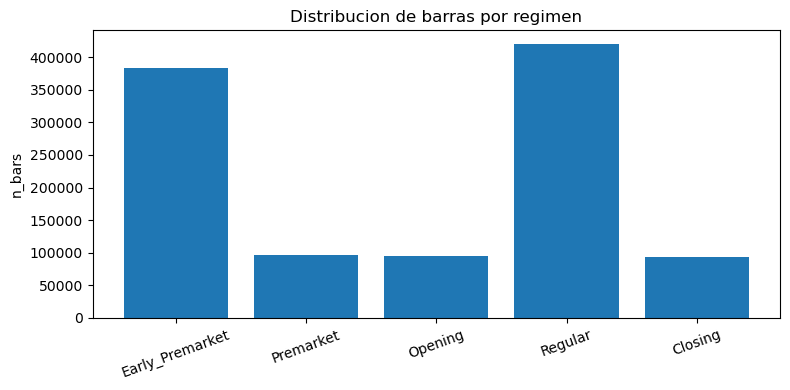

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(result.regime_dist["regime_label"], result.regime_dist["n_bars"])
ax.set_ylabel("n_bars")
ax.set_title("Distribucion de barras por regimen")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Clasificacion de jornadas (`trading_day_audit_v2.parquet`)

Ningun dia se excluye por conteo de barras ni por gaps: cada fecha
calendario del rango tiene un registro con motivo explicito.

In [11]:
print("Total fechas auditadas:", len(result.audit_df))
print("\nPor day_status:")
print(result.audit_df["day_status"].value_counts())
print("\nPor eligibility_category:")
print(result.audit_df["eligibility_category"].value_counts())

Total fechas auditadas: 2309

Por day_status:
day_status
full_coverage                 1482
no_data_weekend                475
partial_undetermined           244
partial_early_close_cme         57
no_data_gap_documented_s00      25
no_data_cme_holiday             11
no_data_undetermined            11
partial_gap_documented_s00       4
Name: count, dtype: int64

Por eligibility_category:
eligibility_category
full_day_eligible          1482
not_model_eligible          526
descriptive_only            182
partial_regime_eligible     119
Name: count, dtype: int64


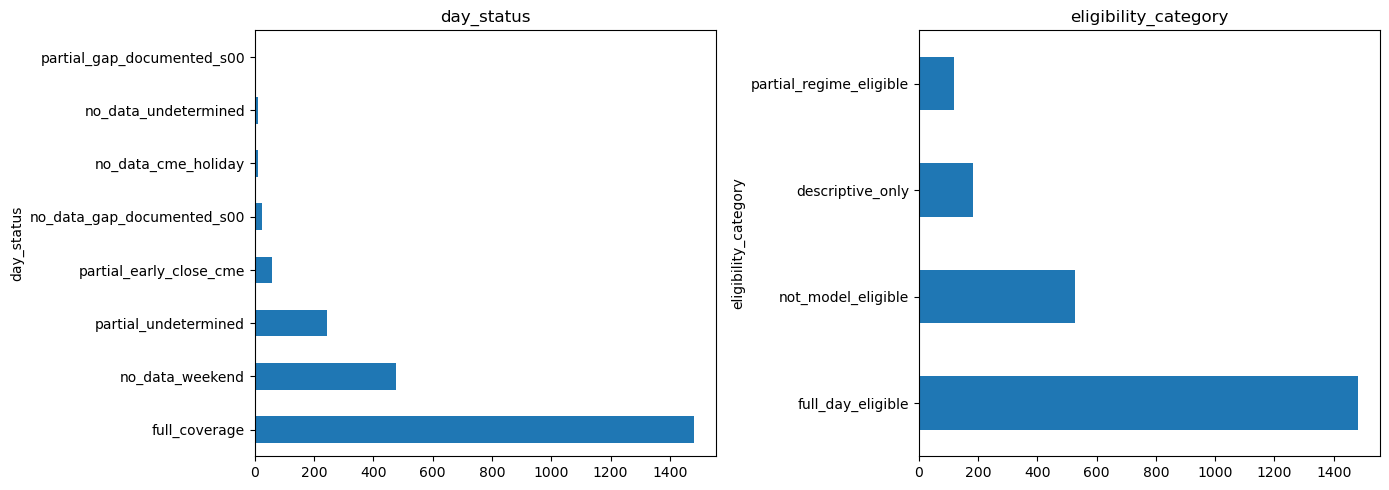

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
result.audit_df["day_status"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("day_status")
result.audit_df["eligibility_category"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("eligibility_category")
plt.tight_layout()
plt.show()

In [13]:
full_days = (result.audit_df["day_status"] == prep.DAY_STATUS_FULL).sum()
less_than_full = (result.audit_df["observed_bars"] < result.audit_df["expected_bars"]).sum()
print(f"Jornadas con exactamente {result.audit_df['expected_bars'].iloc[0]} barras: {full_days}")
print(f"Jornadas con menos de {result.audit_df['expected_bars'].iloc[0]} barras: {less_than_full}")
print("\nDistribucion de missing_bars (jornadas con datos parciales, >0 y <691):")
partial = result.audit_df[(result.audit_df["observed_bars"] > 0) & (result.audit_df["missing_bars"] > 0)]
print(partial["missing_bars"].describe())

Jornadas con exactamente 691 barras: 1482
Jornadas con menos de 691 barras: 827

Distribucion de missing_bars (jornadas con datos parciales, >0 y <691):
count    305.000000
mean     482.098361
std      265.445399
min        1.000000
25%      180.000000
50%      689.000000
75%      690.000000
max      690.000000
Name: missing_bars, dtype: float64


## 6. DST

Verificacion explicita (no solo argumentada) de que las ~14 fechas de
transicion de horario de verano en 2020-2026 no producen minutos duplicados
dentro de la ventana.

In [14]:
print(json.dumps(result.manifest["dst_check"], indent=2, ensure_ascii=False))

{
  "dates_checked": 14,
  "dates_with_duplicates": {}
}


## 7. Gaps de S00 (M23, H25->M25)

Sin filas sinteticas. Los dias dentro de estos rangos quedan marcados
`is_model_eligible=false` con referencia explicita al gap de S00.

In [15]:
gap_days = result.audit_df[result.audit_df["s00_gap_reference"].notna()]
print("Dias afectados por gaps documentados de S00:", len(gap_days))
gap_days.groupby("s00_gap_reference").agg(
    n_dias=("date", "count"),
    todos_no_elegibles=("is_model_eligible", lambda s: (~s).all()),
)

Dias afectados por gaps documentados de S00: 29


,n_dias,todos_no_elegibles
s00_gap_reference,,
s00_gap_H25_M25,17,True
s00_gap_M23,12,True


## 8. Notas

- La ventana `04:30-16:00` y los limites de regimen **no son quiebres
  estructurales optimos** (ver auditoria previa) -- se conservan por
  continuidad metodologica con S02-S07, no como un optimo derivado de los
  datos.
- `timezone_selected` es evidencia empirica robusta (alineacion con
  apertura/cierre/corte de mantenimiento, consistente entre EDT/EST), **no**
  una confirmacion documental del proveedor (`timezone_provider_confirmation: false`).
- `timestamp_semantics` permanece `unknown_not_confirmed`: no se desplazo
  ninguna barra.
- El patron recurrente 16:20-16:30 (2019-2021) queda documentado como
  hallazgo pendiente no bloqueante -- cae dentro de la ventana primaria pero
  no afecta ningun regimen completo (`Closing` termina en 16:00).